# Backtesting Trading Strategies

This notebook is designed to backtest, experiment with, and evaluate various trading strategies to compare their performance against historical data.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

## Signals

In [36]:
class Signal:

    @staticmethod
    def momentum(df, tau, column = 'Close'):
        return df[column].pct_change(tau).shift(1)

## Strategies

Each strategy should be implemented as a function that takes a DataFrame containing `Open`, `High`, `Low`, `Close`, and `Volume`, and returns a DataFrame showing the strategy's performance with the columns `Cash`, `Shares`, and `Value`.

* `Cash`: cash held.
* `Shares`: market value of the shares held.
* `Value`: total portfolio value (`Cash + Shares`).

The starting cash should always be `1` for easier interpretation. Since returns are scale-invariant, this does not affect the results.

Be careful to avoid **lookahead bias**. Signals should generally be calculated using information available at the end of day `t`, shifted to day `t + 1`, and executed using the following day's `Open` price.

Strategy functions should **never modify the input DataFrame**. Always make a copy before adding signals, indicators, or other columns.


In [63]:
def buy_and_hold(df: pd.DataFrame) -> pd.DataFrame:
    """Baseline buy-and-hold strategy"""
    n = df.shape[0]

    cash = np.zeros(n + 1)
    shares = np.zeros(n + 1)

    cash[0] = 1.0
    shares[1:] = cash[0] / df['Open'].iloc[0]

    portfolio_df = pd.DataFrame({
        'Cash': cash[1:],
        'Shares': shares[1:] * df['Close']
    }, index = df.index)
    
    portfolio_df['Value'] = portfolio_df.sum(axis = 1)
    return portfolio_df

In [98]:
def momentum_v1(df, tau, threshold, percent = 0.5) -> pd.DataFrame:
    # Work on a copy so the original DataFrame is not modified
    df = df.copy()

    df['momentum'] = Signal.momentum(df, tau)

    n = df.shape[0]

    # Track cash and number of shares held through time
    # An extra element is used to represent the portfolio before
    # the first trading day
    cash = np.zeros(n + 1)
    shares = np.zeros(n + 1)

    # Start with £1 of cash and no shares
    cash[0] = 1.0

    for i in range(n):
        price = df['Open'].iloc[i]
        momentum = df['momentum'].iloc[i]

        curr_cash = cash[i]
        curr_shares = shares[i]

        # By default, carry the current position forward unchanged
        cash[i + 1] = curr_cash
        shares[i + 1] = curr_shares

        # No trade if the signal is not yet available
        if pd.isna(momentum):
            continue

        # Positive momentum: use part of the available cash to buy shares
        if momentum > threshold:
            if curr_cash > 0:
                amount = curr_cash * percent

                cash[i + 1] -= amount
                shares[i + 1] += amount / price

        # Negative momentum: sell part of the current share position
        elif momentum < -threshold:
            if curr_shares > 0:
                amount = curr_shares * percent

                cash[i + 1] += amount * price
                shares[i + 1] -= amount

    # Convert the number of shares into their market value using
    # the closing price, so the portfolio is marked to market
    portfolio_df = pd.DataFrame({
        'Cash': cash[1:],
        'Shares': shares[1:] * df['Close']
    }, index=df.index)

    # Total portfolio value = cash + market value of shares
    portfolio_df['Value'] = portfolio_df.sum(axis = 1)

    return portfolio_df

## Analytics

In [77]:
def analyse(df: pd.DataFrame) -> pd.DataFrame:
    log_returns = np.log(df['Value']).diff()

    total_return = df['Value'].iloc[-1] - 1
    volatility = log_returns.std() * np.sqrt(252)

    sharpe = (log_returns.mean() / log_returns.std()) * np.sqrt(252)

    return {
        'TotalReturn': total_return,
        'Volatility': volatility,
        'Sharpe': sharpe
    }

## Backtest

In [78]:
universe = [
    'MSFT', 'JNJ', 'JPM', # Large Caps
    'DECK', 'RS', 'WTFC', # Medium Caps
    'MHO', 'MMSI', 'CTS' # Small Caps
]

start = '2015-01-01'
end = '2026-01-01'

In [17]:
data = yf.download(
    universe,
    start, end,
    interval = '1d',
    auto_adjust = True
)

[*********************100%***********************]  9 of 9 completed


In [49]:
data = data.swaplevel('Price', 'Ticker', axis = 1)

In [56]:
universe_data = {
    ticker: data[ticker]
    for ticker in universe
}

In [65]:
analyse(buy_and_hold(universe_data['JPM']))

{'TotalReturn': np.float64(5.931078205808785),
 'Volatility': np.float64(0.27112053146369075),
 'Sharpe': np.float64(0.6491346148900551)}

In [66]:
pd.DataFrame([
    analyse(buy_and_hold(universe_data[ticker]))
    for ticker in universe
], index = universe)

,TotalReturn,Volatility,Sharpe
MSFT,11.159439,0.268619,0.846851
JNJ,1.675646,0.182257,0.494682
JPM,5.931078,0.271121,0.649135
DECK,5.781727,0.419394,0.420728
RS,4.891760,0.296411,0.545476
WTFC,2.475426,0.364323,0.315373
MHO,4.563043,0.453744,0.345230
MMSI,4.053899,0.375909,0.400721
CTS,1.556252,0.341941,0.257275


In [113]:
s1 = buy_and_hold(universe_data['JPM'])
s2 = momentum_v1(universe_data['JPM'], tau = 15, threshold = 0.12, percent = .8)

a1 = analyse(s1)
a2 = analyse(s2)

print('––––– Buy and Hold –––––')
for i, x in a1.items():
    print(f'{i}: {x:.2f}')

print('––––– Momentum –––––')
for i, x in a2.items():
    print(f'{i}: {x:.2f}')

––––– Buy and Hold –––––
TotalReturn: 5.93
Volatility: 0.27
Sharpe: 0.65
––––– Momentum –––––
TotalReturn: 4.34
Volatility: 0.19
Sharpe: 0.79


In this test the buy and hold strategy made a considerably higher return then the momentum approach, moreover the momentum strategy would have had more transactions so if transaction costs are taken into account momentum could be even further then this suggests. However, the momentum approach had both a lower volatility and a higher sharpe ratio, so perhaps modifications of this method are worth looking into.

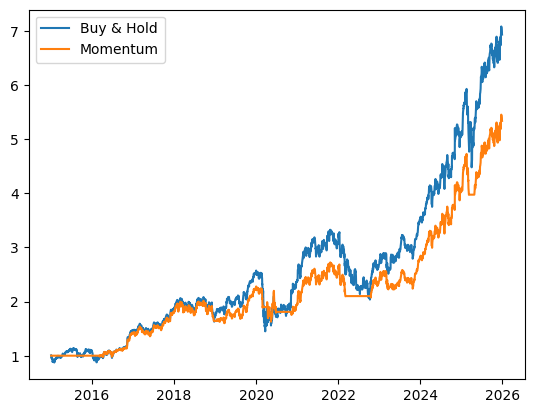

In [114]:
plt.plot(
    s1.index, s1['Value'],
    label = 'Buy & Hold'
)

plt.plot(
    s2.index, s2['Value'],
    label = 'Momentum'
)

plt.legend();